In [1]:
import pandas as pd
from plotnine import *
import numpy as np
from vpop_calibration.api import *

%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_csv("../../../examples/benchmarking/Mavoglurant/Mavoglurant_Dataset.csv")


obs_df = (
    df.loc[df["EVID"] == 0]
    .rename(columns={"ID": "id", "TIME": "time", "DV": "value", "DOSE": "Dose"})[
        ["id", "time", "value", "Dose", "WT"]
    ]
    .astype({"value": "float"})
)
obs_df["time"] = obs_df["time"].apply(lambda t: t * 60 * 60)
obs_df["value"] = obs_df["value"].apply(lambda t: np.log(t))
obs_df["output_name"] = "logC15"
obs_df["protocol_arm"] = "identity"
display(df.head())
display(obs_df.head())

,ID,CMT,EVID,MDV,DV,AMT,TIME,DOSE,OCC,RATE,AGE,SEX,WT,HT,occ
0,793,Venous_Blood,1,1,0.0,25.0,0.000,25.0,1,75,42,1,94.3,1.769997,1
1,793,C15,0,0,491.0,0.0,0.200,25.0,1,0,42,1,94.3,1.769997,1
2,793,C15,0,0,605.0,0.0,0.250,25.0,1,0,42,1,94.3,1.769997,1
3,793,C15,0,0,556.0,0.0,0.367,25.0,1,0,42,1,94.3,1.769997,1
4,793,C15,0,0,310.0,0.0,0.533,25.0,1,0,42,1,94.3,1.769997,1


,id,time,value,Dose,WT,output_name,protocol_arm
1,793,720.0,6.196444,25.0,94.3,logC15,identity
2,793,900.0,6.405228,25.0,94.3,logC15,identity
3,793,1321.2,6.320768,25.0,94.3,logC15,identity
4,793,1918.8,5.736572,25.0,94.3,logC15,identity
5,793,2520.0,5.468060,25.0,94.3,logC15,identity


In [3]:
model = SimworkModelBinding(
    path_to_model="../../../examples/benchmarking/Mavoglurant/cm.json",
    path_to_solving_options="../../../examples/benchmarking/Mavoglurant/sv.json",
    inputs=["KbBR", "CLint", "KbMU", "KbAD", "KbBO", "KbRB", "Dose", "WT"],
    outputs=["logC15"],
)
struct_model = StructuralSimwork(model=model)

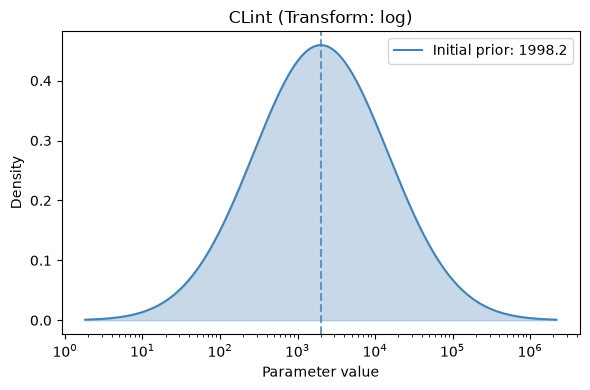

In [12]:
# in nlmixr2
"""
lKbBR = 1.1
lKbMU = 0.3
lKbAD = 2
lCLint = 7.6
lKbBO = 0.03
lKbRB = 0.3
eta.LClint ~ 4
eta.LKbBR ~ 0.5
eta.LKbMU ~ 0.5
eta.LKbAD ~ 0.5
eta.LKbBO ~ 0.5
eta.LKbRB ~ 0.5
add.err <- 1
"""

input_params = {
    "model_intrinsic": {
        "KbBR": {"prior": np.exp(1.1)},
        "KbMU": {"prior": np.exp(0.3)},
        "KbAD": {"prior": np.exp(2)},
        "KbBO": {"prior": np.exp(0.03)},
        "KbRB": {"prior": np.exp(0.3)},
    },
    "pdu": {
        "CLint": {"prior": np.exp(7.6), "prior_omega": 4},
    },
    "pdk": {"WT", "Dose"},
    "error_model": {
        "logC15": {"error_type": "additive", "initial_variance": 1},
    },
}
config = Config(
    saem=SaemConfigDict(
        nb_iter_burnin=10,
        nb_iter_learning=190,
        nb_iter_smoothing=300,
        nb_mcmc_transitions=1,
        annealing_factor=0.95,
        fixed_effects_lr=1e-3,
        fixed_effects_grad_scale=1e-3,
        learning_rate_power=0.7,
        live_plot=True,
        progress_bars=True,
        logging=False,
        fixed_effects_patient_batch_size=20,
        plot_frames=5,
    ),
    nlme=NlmeConfigDict(nb_chains=1),
)
nlme_model = NlmeModel(
    df=obs_df, input_params=input_params, structural_model=struct_model, config=config
)
nlme_model.initial_estimates.plot_distribution()

  0%|          | 0/500 [00:00<?, ?it/s]

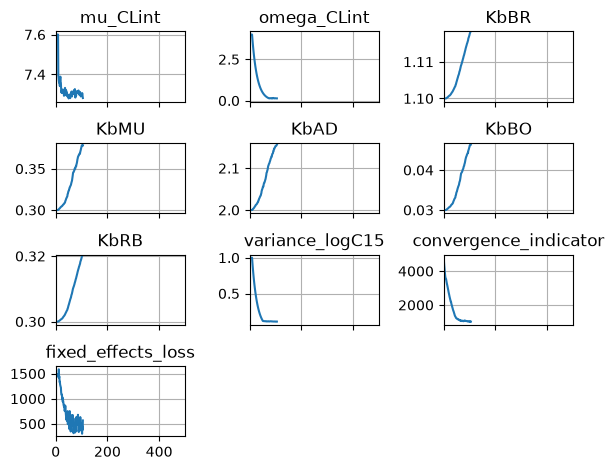

Interrupted gracefully at iteration 110.


In [13]:
nlme_model.optimizer.run()

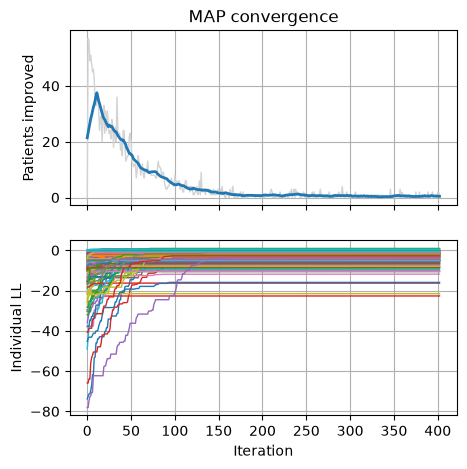

  0%|          | 0/500 [00:00<?, ?it/s]

Interrupting sampling.


In [14]:
nlme_model.diagnostics.sample_conditional_distribution(nb_samples=500)

In [15]:
run_id = "20260925_1615"

In [16]:
nlme_model.diagnostics.sampler.map_parameters_df.to_csv(
    f"jinko_map_{run_id}.csv", index=False
)

In [17]:
# nlme_model.diagnostics.sample_conditional_distribution(400)
nlme_model.diagnostics.compute_vpc(quantiles=[0.05, 0.5, 0.95])
vpc_py = nlme_model.diagnostics.vpc
vpc_py["model"] = "Sbml"
vpc_py.to_csv(f"jinko_vpc_{run_id}.csv", index=False)
print(vpc_py.head(12))

    bin  quantile     q_obs  pred_median  pred_lower  pred_upper  bin_center  \
0     0      0.05  3.645969     3.740329    3.681767    3.790298      2700.0   
1     0      0.50  5.438079     5.416324    5.385340    5.446777      2700.0   
2     0      0.95  6.572560     7.022883    6.965840    7.076360      2700.0   
3     1      0.05  2.609329     2.453554    2.367717    2.540193     26429.4   
4     1      0.50  3.453152     3.389819    3.334180    3.433998     26429.4   
5     1      0.95  4.318117     4.353108    4.254958    4.433819     26429.4   
6     2      0.05  2.160535     1.943585    1.825375    2.041099     44100.0   
7     2      0.50  2.901406     2.832248    2.767067    2.903812     44100.0   
8     2      0.95  3.865349     3.780049    3.657322    3.903098     44100.0   
9     5      0.05  1.062357     1.007028    0.874289    1.129862     87120.0   
10    5      0.50  1.967112     1.929645    1.858185    1.998994     87120.0   
11    5      0.95  3.143655     2.954267

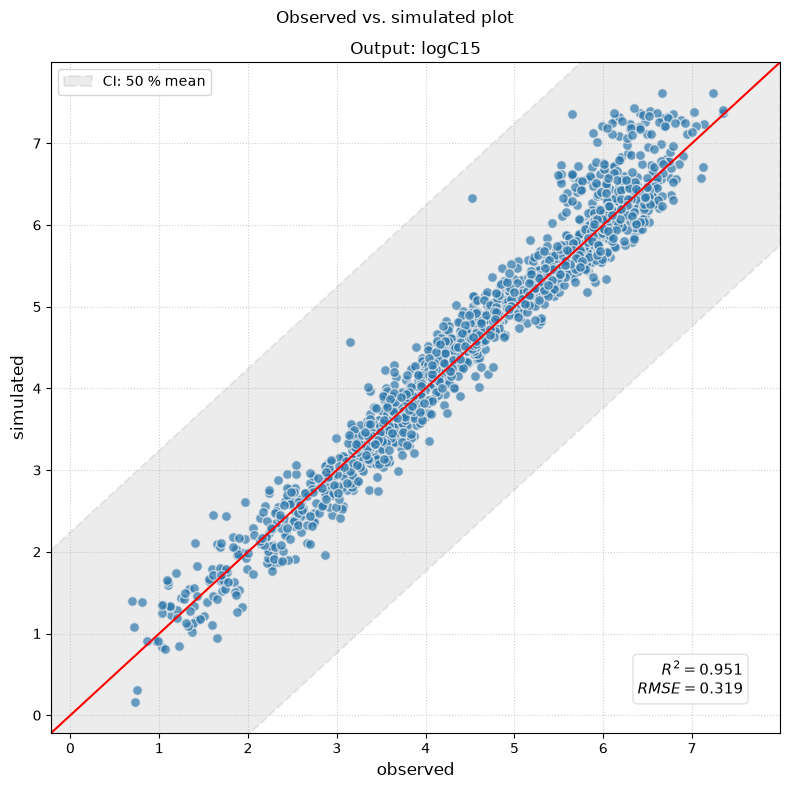

In [18]:
nlme_model.plot.map_estimates_gof()

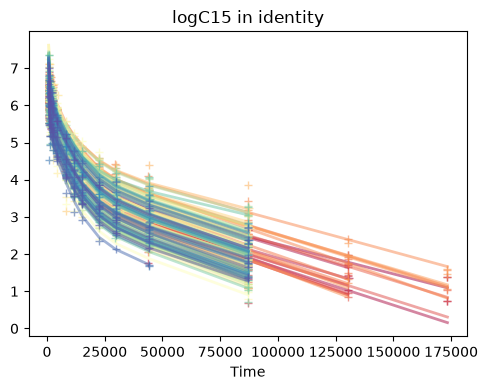

In [19]:
nlme_model.plot.map_estimates()

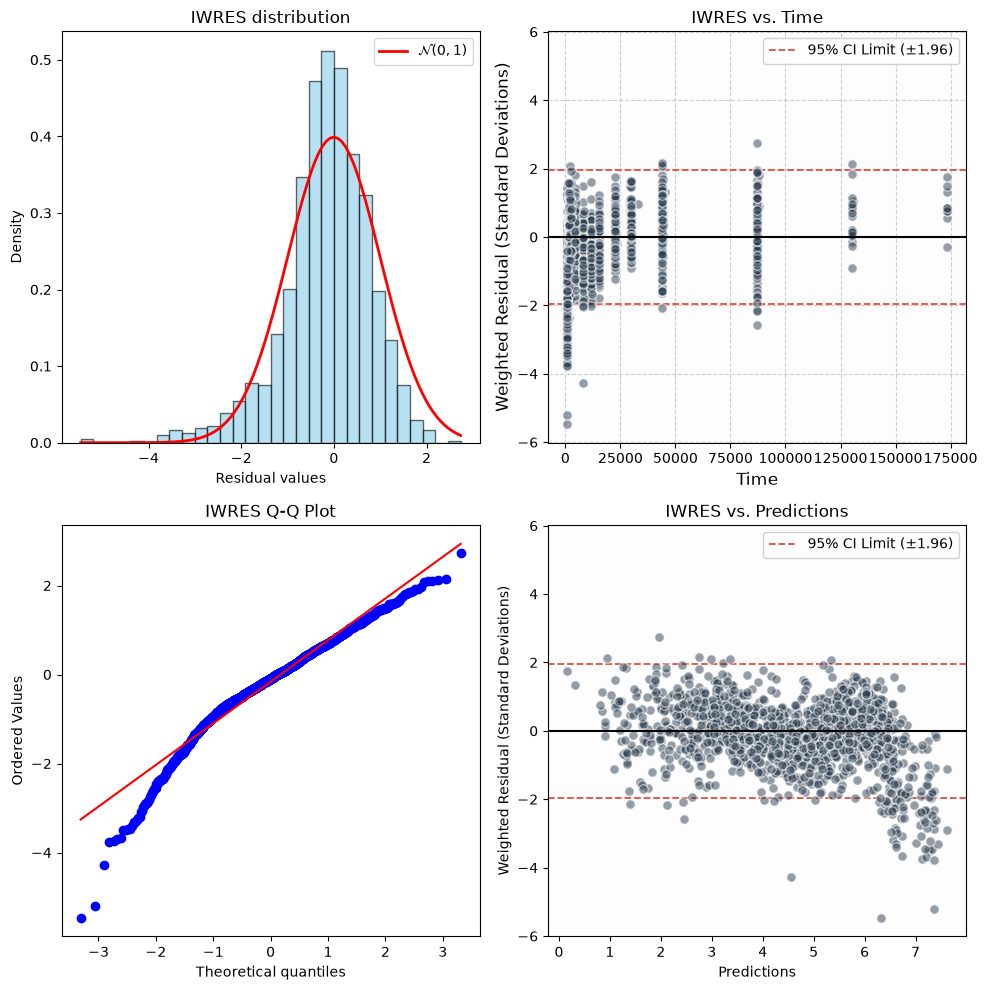

In [20]:
nlme_model.plot.weighted_residuals("iwres")

/home/eliott.tixier/git/pysaem/.venv-full/lib/python3.13/site-packages/torch/utils/_device.py:109: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)


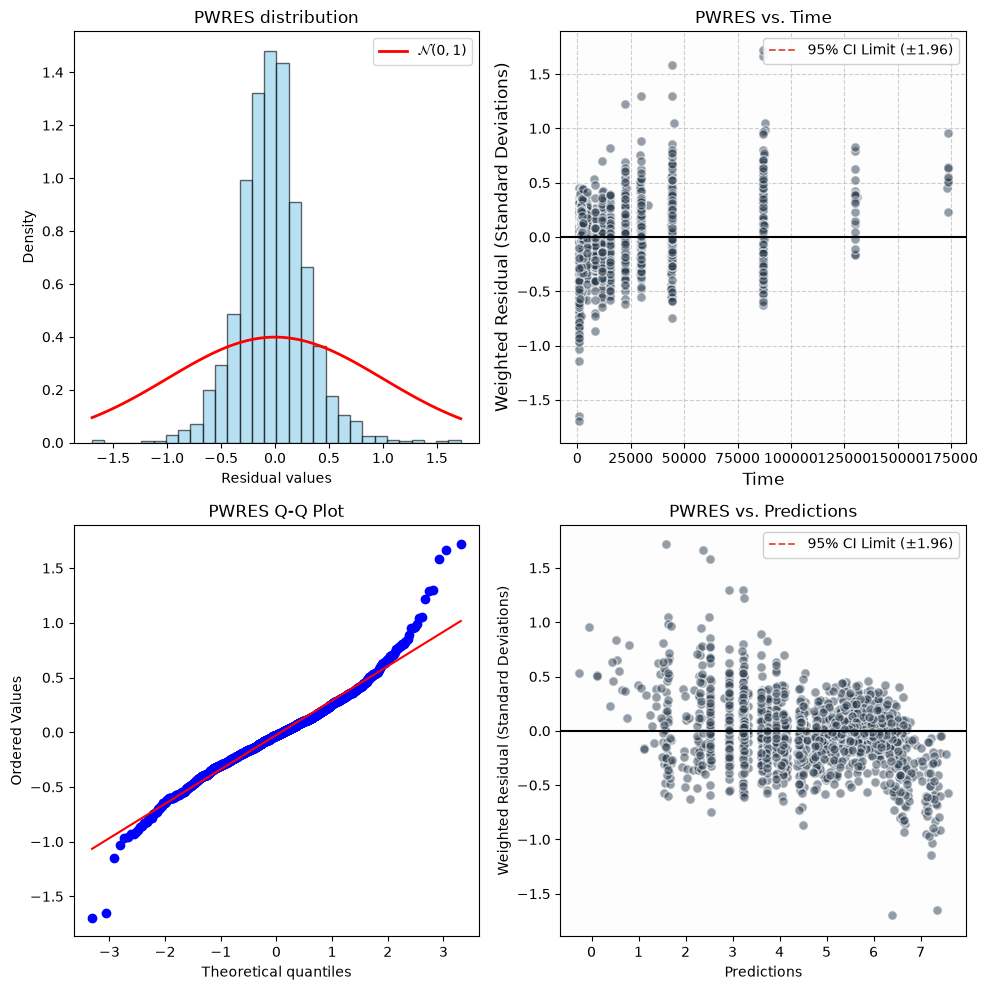

In [21]:
nlme_model.plot.weighted_residuals("pwres")

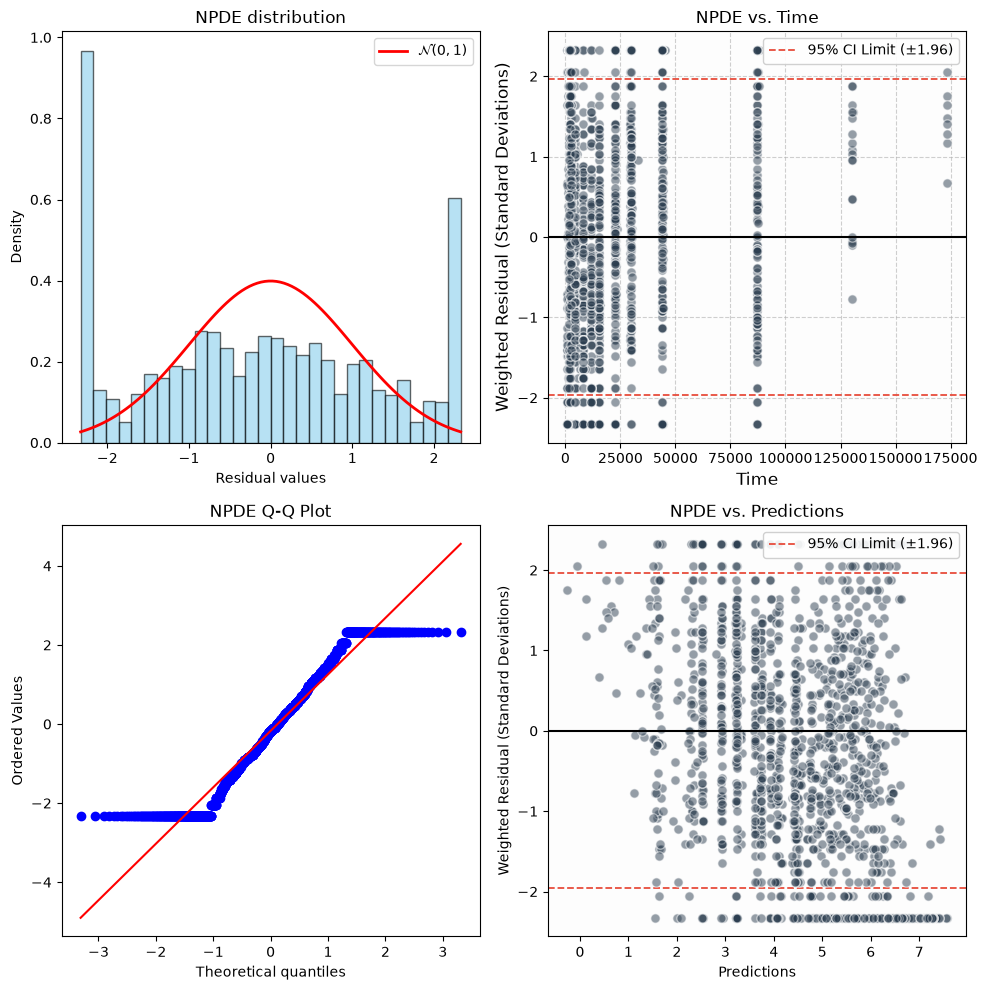

In [22]:
nlme_model.plot.weighted_residuals("npde")

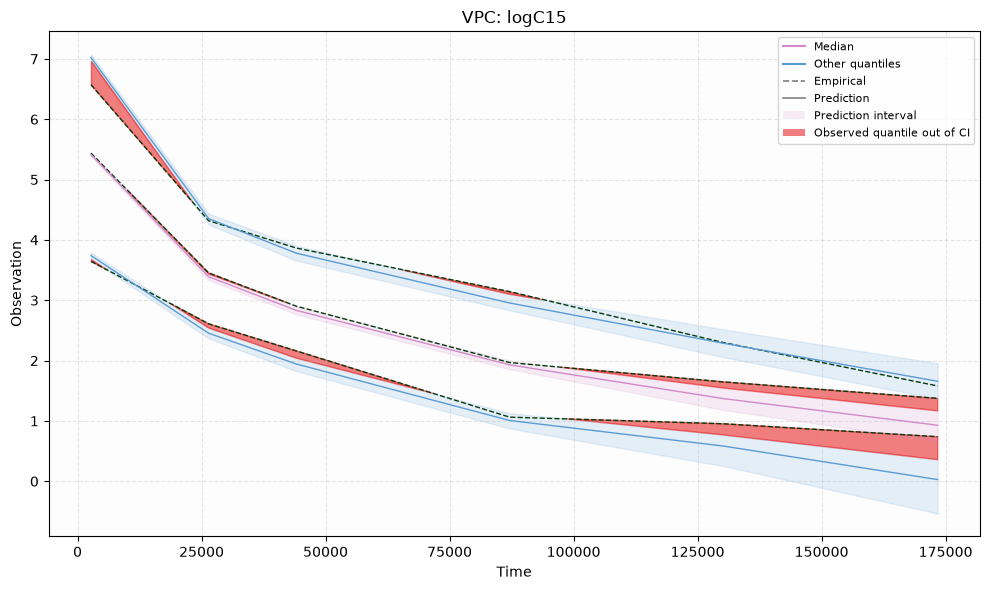

In [23]:
nlme_model.plot.vpc(nb_bins=10)